In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC

sys.path.insert(0, os.path.abspath('..'))
import gym_unbalanced_disk

## Environment

Same setup as the PPO swing-up: `unbalanced-disk-sincos-v0` with obs = [sin θ, cos θ, ω],
action u ∈ [-3, 3] V, 300 steps × 0.025 s = 7.5 s per episode.

Two modifications carried over from the PPO notebook:
- `Fc = 10.0` — matches hardware sysid (real friction is higher than the default 6.06)
- Cosine reward with velocity penalty near the top:

$$r = \frac{1 - \cos\theta}{2} \cdot (1 - 0.01\,\omega^2)$$

SB3's SAC requires a 1-D action space (it reshapes actions internally), so we wrap the
environment to convert the 0-D Box to shape (1,) and unwrap it on the way in.

In [ ]:
class ActionWrapper1D(gym.ActionWrapper):
    """Converts 0-D Box action space to (1,) so SB3 SAC works correctly."""
    def __init__(self, env):
        super().__init__(env)
        umax = env.unwrapped.umax
        self.action_space = spaces.Box(
            low=np.array([-umax], dtype=np.float32),
            high=np.array([ umax], dtype=np.float32),
            dtype=np.float32
        )

    def action(self, act):
        return np.float32(act[0])


class SimToRealWrapper(gym.Wrapper):
    """
    Domain randomisation for sim-to-real transfer.

    - th_noise_std    : angle encoder noise (rad)
    - omega_noise_std : velocity noise (ω estimated by differencing encoder ticks)
    - fc_range        : Coulomb friction randomised each episode

    Action delay excluded — it makes the task ~5x harder to converge.
    Noise + Fc randomisation are sufficient for robust sim-to-real transfer.
    """
    def __init__(self, env, th_noise_std=0.01, omega_noise_std=0.05, fc_range=(8.0, 12.0)):
        super().__init__(env)
        self.th_noise_std    = th_noise_std
        self.omega_noise_std = omega_noise_std
        self.fc_range        = fc_range

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.env.unwrapped.Fc = float(np.random.uniform(*self.fc_range))
        return self._add_noise(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._add_noise(obs), reward, terminated, truncated, info

    def _add_noise(self, obs):
        obs = obs.copy().astype(np.float64)
        th_n  = np.random.normal(0, self.th_noise_std)
        obs[0] = obs[0] * np.cos(th_n) + obs[1] * np.sin(th_n)
        obs[1] = obs[1] * np.cos(th_n) - obs[0] * np.sin(th_n)
        obs[2] += np.random.normal(0, self.omega_noise_std)
        return obs.astype(np.float32)


def make_env(domain_rand=True):
    env = gym.make('unbalanced-disk-sincos-v0')
    env.unwrapped.Fc = 10.0

    def reward_fn(self):
        pos = 0.5 * (1.0 - np.cos(self.th))
        return pos * (1.0 - 0.01 * self.omega ** 2)

    env.unwrapped.reward_fun = reward_fn
    if domain_rand:
        env = SimToRealWrapper(env)
    return ActionWrapper1D(env)


env = make_env()
print('obs space   :', env.observation_space)
print('action space:', env.action_space)

## SAC — Soft Actor-Critic

SAC is an **off-policy** actor-critic algorithm designed for continuous action spaces.
It differs from PPO in three key ways:

| | PPO | SAC |
|---|---|---|
| Data | On-policy rollouts | Replay buffer (off-policy) |
| Critic | Value function V(s) | Two Q-functions Q₁(s,u), Q₂(s,u) |
| Exploration | Entropy coefficient (tuned manually) | Automatic entropy tuning |
| Sample efficiency | Lower | Higher |

### Objective

SAC maximises a entropy-augmented return:

$$J(\pi) = \mathbb{E}\left[\sum_t r_t + \alpha\,\mathcal{H}(\pi(\cdot|s_t))\right]$$

where α is a temperature that is learned automatically — it adapts so the policy
maintains a target entropy, preventing both premature collapse and excessive randomness.

### Two Q-functions

To reduce overestimation bias (a known problem in Q-learning), SAC trains two
independent critic networks and takes the minimum:

$$y = r + \gamma\,\min(Q_1(s', \tilde u'),\, Q_2(s', \tilde u')) - \alpha\log\pi(\tilde u'|s')$$

### Why SAC is better than PPO here

The unbalanced disc has 300 steps per episode and resets from the bottom every time.
PPO must discard all collected experience after each policy update. SAC stores every
transition in a replay buffer and can learn from the same data many times, making
it significantly more sample-efficient for this task.

In [12]:
HERE       = os.path.dirname(os.path.abspath('sac.ipynb'))
MODEL_PATH = os.path.join(HERE, 'sac_swingup.zip')

if os.path.exists(MODEL_PATH):
    model = SAC.load(MODEL_PATH)
    print(f'Loaded saved model from {MODEL_PATH}')
else:
    env = make_env(domain_rand=True)
    model = SAC(
        'MlpPolicy',
        env,
        learning_rate=3e-4,
        gamma=0.99,
        buffer_size=300_000,
        batch_size=256,
        ent_coef='auto',
        learning_starts=5_000,
        train_freq=1,
        gradient_steps=2,
        verbose=1,
        seed=42,
    )
    model.learn(total_timesteps=200_000)  # increase to 500_000 if result is poor
    model.save(MODEL_PATH)
    print(f'Training done, saved to {MODEL_PATH}')

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 300      |
|    ep_rew_mean     | 3.58     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 4159     |
|    time_elapsed    | 0        |
|    total_timesteps | 1200     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 300      |
|    ep_rew_mean     | 3.57     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 4348     |
|    time_elapsed    | 0        |
|    total_timesteps | 2400     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 300      |
|    ep_rew_mean     | 4.19     |
| time/              |          |
|    episodes        | 12       |
|    fps             |

## Evaluation

Total reward: 2.4 / 300


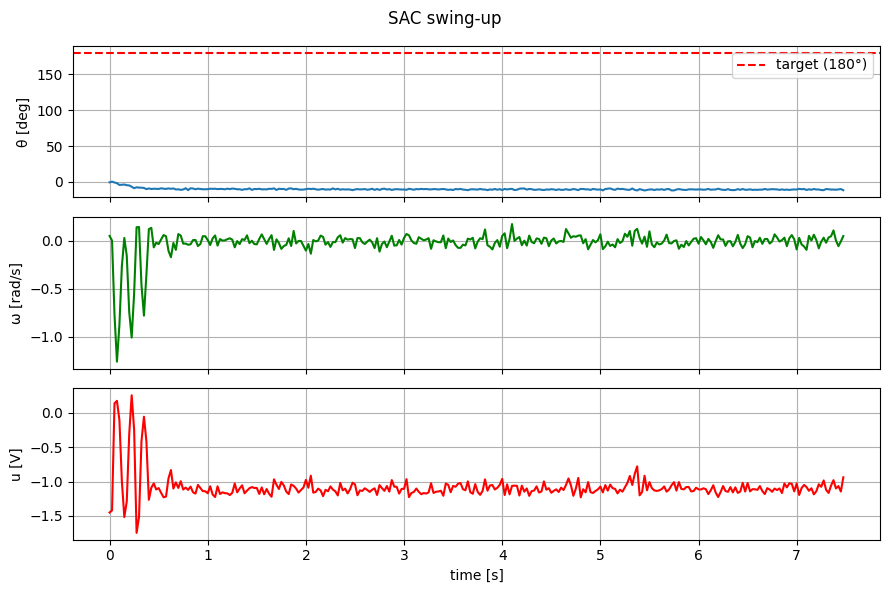

In [13]:
env = make_env()
obs, _ = env.reset()
obs_hist, act_hist, rew_hist = [], [], []

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs_hist.append(obs.copy())
    act_hist.append(float(action[0]))
    obs, r, terminated, truncated, _ = env.step(action)
    rew_hist.append(r)
    done = terminated or truncated

obs_arr = np.array(obs_hist)
th_deg  = np.degrees(np.arctan2(obs_arr[:, 0], obs_arr[:, 1]))
t       = np.arange(len(th_deg)) * 0.025

print(f'Total reward: {sum(rew_hist):.1f} / {len(rew_hist)}')

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, th_deg)
axes[0].axhline(180, color='r', ls='--', label='target (180°)')
axes[0].set_ylabel('θ [deg]');  axes[0].legend();  axes[0].grid(True)
axes[1].plot(t, obs_arr[:, 2], 'g')
axes[1].set_ylabel('ω [rad/s]');  axes[1].grid(True)
axes[2].plot(t, act_hist, 'r')
axes[2].set_ylabel('u [V]');  axes[2].set_xlabel('time [s]');  axes[2].grid(True)
plt.suptitle('SAC swing-up')
plt.tight_layout()
plt.show()

## Multi-episode Statistics

Run 20 episodes and report mean ± std total reward to get a stable performance estimate.

Mean reward : 2.4
Std  reward : 0.2
Min / Max   : 2.2 / 2.7


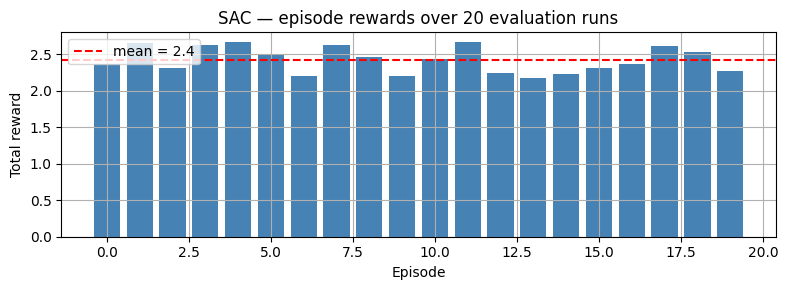

In [14]:
N_EVAL = 20
episode_rewards = []

for _ in range(N_EVAL):
    env_e = make_env()
    obs, _ = env_e.reset()
    total  = 0.0
    done   = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, terminated, truncated, _ = env_e.step(action)
        total += r
        done = terminated or truncated
    episode_rewards.append(total)

rewards_arr = np.array(episode_rewards)
print(f'Mean reward : {rewards_arr.mean():.1f}')
print(f'Std  reward : {rewards_arr.std():.1f}')
print(f'Min / Max   : {rewards_arr.min():.1f} / {rewards_arr.max():.1f}')

plt.figure(figsize=(8, 3))
plt.bar(range(N_EVAL), rewards_arr, color='steelblue')
plt.axhline(rewards_arr.mean(), color='r', ls='--', label=f'mean = {rewards_arr.mean():.1f}')
plt.xlabel('Episode');  plt.ylabel('Total reward');  plt.legend();  plt.grid(True)
plt.title('SAC — episode rewards over 20 evaluation runs')
plt.tight_layout()
plt.show()

## Live Visualisation

Opens a pygame window and runs the policy in real time.
**Interrupt the kernel** (■ button) to close — the `finally` block cleans up pygame.

In [ ]:
import time

def reward_fn(self):
    pos = 0.5 * (1.0 - np.cos(self.th))
    return pos * (1.0 - 0.01 * self.omega ** 2)

env_vis = gym_unbalanced_disk.UnbalancedDisk_sincos()
env_vis.unwrapped.Fc = 10.0
env_vis.unwrapped.reward_fun = reward_fn
env_vis = ActionWrapper1D(env_vis)

obs, _ = env_vis.reset()
total_reward = 0.0
step = 0

try:
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env_vis.step(action)
        total_reward += reward
        step += 1
        env_vis.render()
        time.sleep(env_vis.unwrapped.dt)
        if terminated or truncated:
            th_deg = np.degrees(np.arctan2(obs[0], obs[1]))
            print(f'Episode done — steps: {step}  reward: {total_reward:.1f}/300  final θ: {th_deg:.1f}°')
            total_reward = 0.0
            step = 0
            obs, _ = env_vis.reset()
finally:
    env_vis.close()